In [1]:
import os
print("os ok")

os ok


In [2]:
import numpy as np
print("numpy ok")

numpy ok


In [3]:
import torch
print("torch ok")

torch ok


In [4]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
print("torch ok:", torch.__version__)

torch ok: 2.12.0+cpu


In [5]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [6]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
print("Environment variable set")

Environment variable set


In [7]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

print("✅ Sab imports ho gaye")
print("GPU hai ya nahi:", torch.cuda.is_available())

✅ Sab imports ho gaye
GPU hai ya nahi: False


In [8]:
base_path = "data1a"

for root, dirs, files in os.walk(base_path):
    print(root, "-> files:", len(files))

data1a -> files: 0
data1a\training -> files: 0
data1a\training\00-damage -> files: 920
data1a\training\01-whole -> files: 920
data1a\validation -> files: 0
data1a\validation\00-damage -> files: 230
data1a\validation\01-whole -> files: 230


In [9]:
class CarDamageDataset(Dataset):
    def __init__(self, damage_dir, whole_dir):
        self.images = []
        self.labels = []

        for img_file in os.listdir(damage_dir):
            try:
                img = Image.open(os.path.join(damage_dir, img_file)).convert('RGB').resize((64, 64))
                img_array = np.array(img) / 255.0
                self.images.append(torch.FloatTensor(img_array).permute(2, 0, 1))
                self.labels.append(1)   # damage = 1
            except:
                pass

        for img_file in os.listdir(whole_dir):
            try:
                img = Image.open(os.path.join(whole_dir, img_file)).convert('RGB').resize((64, 64))
                img_array = np.array(img) / 255.0
                self.images.append(torch.FloatTensor(img_array).permute(2, 0, 1))
                self.labels.append(0)   # whole = 0
            except:
                pass

        print(f"Loaded {len(self.images)} images")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], torch.tensor(self.labels[idx], dtype=torch.long)

print("✅ Dataset class defined")

✅ Dataset class defined


In [10]:
train_dataset = CarDamageDataset(
    "data1a/training/00-damage",
    "data1a/training/01-whole"
)

val_dataset = CarDamageDataset(
    "data1a/validation/00-damage",
    "data1a/validation/01-whole"
)

print("✅ Train size:", len(train_dataset), "| Val size:", len(val_dataset))

Loaded 1840 images
Loaded 460 images
✅ Train size: 1840 | Val size: 460


In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("DataLoaders ready")
print("Batches per epoch:", len(train_loader))

DataLoaders ready
Batches per epoch: 58


In [12]:
class DamageCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1 = nn.Linear(8 * 4 * 4, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DamageCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model ready on", device)

Model ready on cpu


In [13]:
EPOCHS = 3
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    start = time.time()

    # ---- Training ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---- Validation ----
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            v_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            v_correct += (preds == labels).sum().item()
            v_total += labels.size(0)

    val_loss = v_loss / v_total
    val_acc = v_correct / v_total
    epoch_time = time.time() - start

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Time: {epoch_time:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("   -> Best model saved!")

print("Training done. Best Validation Accuracy:", best_val_acc)

Epoch 1/3 | Train Acc: 0.5196 | Val Acc: 0.5043 | Time: 1.5s
   -> Best model saved!
Epoch 2/3 | Train Acc: 0.5391 | Val Acc: 0.5065 | Time: 1.3s
   -> Best model saved!
Epoch 3/3 | Train Acc: 0.5576 | Val Acc: 0.5304 | Time: 1.3s
   -> Best model saved!
Training done. Best Validation Accuracy: 0.5304347826086957


In [14]:
class DamageCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DamageCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model ready on", device)

Model ready on cpu


In [16]:
EPOCHS = 10
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_correct += (outputs.argmax(1) == labels).sum().item()
            v_total += labels.size(0)
    val_acc = v_correct / v_total

    print(f"Epoch {epoch+1}: Train {train_acc:.3f} | Val {val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

print("Best Val Accuracy:", best_val_acc)

Epoch 1: Train 0.877 | Val 0.770
Epoch 2: Train 0.884 | Val 0.774
Epoch 3: Train 0.894 | Val 0.787
Epoch 4: Train 0.897 | Val 0.783
Epoch 5: Train 0.906 | Val 0.774
Epoch 6: Train 0.918 | Val 0.796
Epoch 7: Train 0.921 | Val 0.776
Epoch 8: Train 0.938 | Val 0.791
Epoch 9: Train 0.935 | Val 0.789
Epoch 10: Train 0.942 | Val 0.774
Best Val Accuracy: 0.7956521739130434


In [17]:
class DamageCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DamageCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model ready on", device)

Model ready on cpu


In [18]:
EPOCHS = 15
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_correct += (outputs.argmax(1) == labels).sum().item()
            v_total += labels.size(0)
    val_acc = v_correct / v_total

    print(f"Epoch {epoch+1}: Train {train_acc:.3f} | Val {val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

print("Best Val Accuracy:", best_val_acc)

Epoch 1: Train 0.522 | Val 0.576
Epoch 2: Train 0.599 | Val 0.635
Epoch 3: Train 0.667 | Val 0.685
Epoch 4: Train 0.695 | Val 0.715
Epoch 5: Train 0.707 | Val 0.720
Epoch 6: Train 0.732 | Val 0.720
Epoch 7: Train 0.747 | Val 0.730
Epoch 8: Train 0.758 | Val 0.735
Epoch 9: Train 0.753 | Val 0.754
Epoch 10: Train 0.771 | Val 0.772
Epoch 11: Train 0.785 | Val 0.783
Epoch 12: Train 0.798 | Val 0.767
Epoch 13: Train 0.807 | Val 0.767
Epoch 14: Train 0.820 | Val 0.789
Epoch 15: Train 0.830 | Val 0.804
Best Val Accuracy: 0.8043478260869565


In [20]:
EPOCHS = 15
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_correct += (outputs.argmax(1) == labels).sum().item()
            v_total += labels.size(0)
    val_acc = v_correct / v_total

    print(f"Epoch {epoch+1}: Train {train_acc:.3f} | Val {val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

print("Best Val Accuracy:", best_val_acc)

Epoch 1: Train 0.829 | Val 0.793
Epoch 2: Train 0.839 | Val 0.798
Epoch 3: Train 0.843 | Val 0.787
Epoch 4: Train 0.851 | Val 0.789
Epoch 5: Train 0.859 | Val 0.811
Epoch 6: Train 0.850 | Val 0.811
Epoch 7: Train 0.868 | Val 0.800
Epoch 8: Train 0.870 | Val 0.800
Epoch 9: Train 0.880 | Val 0.804
Epoch 10: Train 0.886 | Val 0.804
Epoch 11: Train 0.893 | Val 0.793
Epoch 12: Train 0.892 | Val 0.800
Epoch 13: Train 0.903 | Val 0.804
Epoch 14: Train 0.904 | Val 0.802
Epoch 15: Train 0.919 | Val 0.813
Best Val Accuracy: 0.8130434782608695


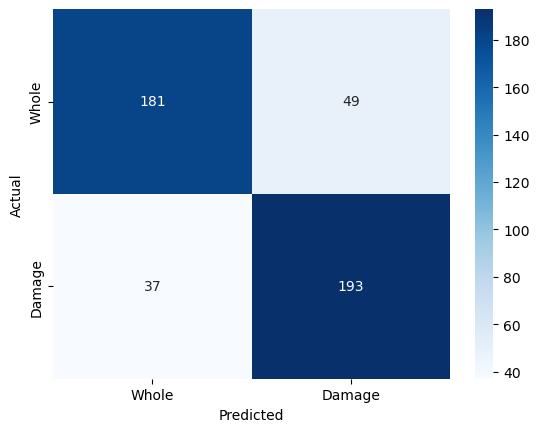

              precision    recall  f1-score   support

       Whole       0.83      0.79      0.81       230
      Damage       0.80      0.84      0.82       230

    accuracy                           0.81       460
   macro avg       0.81      0.81      0.81       460
weighted avg       0.81      0.81      0.81       460



In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Whole", "Damage"], yticklabels=["Whole", "Damage"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

print(classification_report(all_labels, all_preds, target_names=["Whole", "Damage"]))

In [22]:
def predict_image(path):
    img = Image.open(path).convert("RGB").resize((64, 64))
    arr = np.array(img) / 255.0
    tensor = torch.FloatTensor(arr).permute(2, 0, 1).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(tensor)
        probs = F.softmax(out, dim=1)[0]
        pred = torch.argmax(probs).item()

    label = "Damaged" if pred == 1 else "Whole"
    print(f"Prediction: {label} (confidence: {probs[pred]:.2%})")
    return label

# Test karo kisi bhi validation image pe:
predict_image("data1a/validation/00-damage/" + os.listdir("data1a/validation/00-damage")[0])

Prediction: Whole (confidence: 90.63%)


'Whole'

In [23]:
import random

damage_folder = "data1a/validation/00-damage"
whole_folder = "data1a/validation/01-whole"

print("--- Damage images test ---")
damage_files = random.sample(os.listdir(damage_folder), 5)
for f in damage_files:
    predict_image(os.path.join(damage_folder, f))

print("\n--- Whole images test ---")
whole_files = random.sample(os.listdir(whole_folder), 5)
for f in whole_files:
    predict_image(os.path.join(whole_folder, f))

--- Damage images test ---
Prediction: Damaged (confidence: 99.56%)
Prediction: Damaged (confidence: 98.84%)
Prediction: Damaged (confidence: 83.97%)
Prediction: Damaged (confidence: 99.44%)
Prediction: Damaged (confidence: 74.34%)

--- Whole images test ---
Prediction: Whole (confidence: 61.79%)
Prediction: Damaged (confidence: 82.00%)
Prediction: Whole (confidence: 64.34%)
Prediction: Whole (confidence: 87.91%)
Prediction: Whole (confidence: 62.04%)


In [24]:
import os
print(os.getcwd())

E:\Kaggale Project\Hackton


In [27]:
pip install -r requirements.txt

  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached fpdf2-2.8.7-py3-none-any.whl.metadata (81 kB)
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   -----------------

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\dell\\AppData\\Local\\Temp\\pip-unpack-9ivmmdu6\\opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl'
Consider using the `--user` option or check the permissions.



In [28]:
!pip install ipywidgets --quiet
print("Done")

Done


In [29]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import io
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display, clear_output, FileLink

class DamageCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 2)
        self.gradients = None
        self.activations = None

    def _save_gradient(self, grad):
        self.gradients = grad

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = F.relu(self.conv2(x))
        self.activations = x
        if x.requires_grad:
            x.register_hook(self._save_gradient)
        x = self.pool(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

model = DamageCNN()
model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))
model.eval()
print("✅ Model loaded successfully")

✅ Model loaded successfully


In [30]:
def preprocess_image(pil_img):
    img = pil_img.resize((64, 64))
    arr = np.array(img) / 255.0
    return torch.FloatTensor(arr).permute(2, 0, 1).unsqueeze(0)

def generate_gradcam(model, input_tensor, class_idx):
    model.zero_grad()
    output = model(input_tensor)
    score = output[0, class_idx]
    score.backward()
    gradients = model.gradients[0]
    activations = model.activations[0].detach()
    weights = gradients.mean(dim=(1, 2))
    cam = torch.zeros(activations.shape[1:])
    for i, w in enumerate(weights):
        cam += w * activations[i]
    cam = F.relu(cam)
    cam -= cam.min()
    if cam.max() > 0:
        cam /= cam.max()
    return cam.numpy(), F.softmax(output, dim=1)[0].detach()

def overlay_heatmap(cam, original_pil_img, alpha=0.45):
    base = np.array(original_pil_img.resize((256, 256))).astype(np.float32)
    cam_img = Image.fromarray(np.uint8(cam * 255)).resize((256, 256), resample=Image.BILINEAR)
    cam_resized = np.array(cam_img) / 255.0
    heat_color = plt.cm.jet(cam_resized)[:, :, :3] * 255.0
    overlay = base * (1 - alpha) + heat_color * alpha
    return np.clip(overlay, 0, 255).astype(np.uint8)

def compute_tabular_risk(vehicle_age, mileage, repair_cost, policy_type):
    risk, reasons = 0, []
    if vehicle_age > 10:
        risk += 15; reasons.append("vehicle age over 10 years")
    if mileage > 150000:
        risk += 15; reasons.append("unusually high mileage")
    if repair_cost > 5000:
        risk += 25; reasons.append("high repair cost estimate")
    if policy_type == "Third-Party":
        risk += 10; reasons.append("third-party policy needs extra verification")
    return min(risk, 100), reasons

SUSPICIOUS_KEYWORDS = ["stolen", "total loss", "hit and run", "no witness",
                        "cash settlement", "unregistered", "no police report"]

def analyze_claim_text(text):
    text_lower = text.lower()
    flags = [kw for kw in SUSPICIOUS_KEYWORDS if kw in text_lower]
    return min(len(flags) * 25, 100), flags

def generate_explanation(damage_label, confidence, tabular_risk, tabular_reasons, text_risk, text_flags, final_decision):
    parts = [f"The vision model classified the vehicle as {damage_label} with {confidence:.1%} confidence."]
    parts.append("Policy/claim data raised: " + "; ".join(tabular_reasons) + "." if tabular_reasons else "No unusual risk factors in policy/vehicle data.")
    parts.append("Flagged terms in description: " + ", ".join(text_flags) + "." if text_flags else "No suspicious language detected in description.")
    parts.append(f"Combined assessment: {final_decision}.")
    return " ".join(parts)

def compute_final_decision(damage_label, confidence, tabular_risk, text_risk):
    if damage_label == "Whole" and tabular_risk < 30 and text_risk < 30:
        return "Auto-Approve (No Damage Detected)"
    if damage_label == "Damaged" and confidence > 0.85 and tabular_risk < 40 and text_risk < 20:
        return "Approve for Repair Payout"
    if tabular_risk >= 50 or text_risk >= 40:
        return "Flag for Manual Fraud Review"
    return "Route to Human Adjuster"

LOG_FILE = "claims_log.csv"

def log_decision(claim_id, damage_label, confidence, tabular_risk, text_risk, final_decision, human_decision, notes=""):
    row = {"claim_id": claim_id, "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
           "ai_damage_label": damage_label, "ai_confidence": round(float(confidence), 3),
           "tabular_risk": tabular_risk, "text_risk": text_risk,
           "ai_recommendation": final_decision, "human_decision": human_decision, "notes": notes}
    df_row = pd.DataFrame([row])
    if os.path.exists(LOG_FILE):
        df_row.to_csv(LOG_FILE, mode="a", header=False, index=False)
    else:
        df_row.to_csv(LOG_FILE, mode="w", header=True, index=False)

def generate_pdf_report(claim_id, r, human_decision_value):
    try:
        from fpdf import FPDF
        pdf = FPDF()
        pdf.add_page()
        pdf.set_font("Arial", "B", 16)
        pdf.cell(0, 10, "AI Insurance Claim Assessment Report")
        pdf.ln(12)
        pdf.set_font("Arial", "", 11)
        for line in [
            f"Claim ID: {claim_id}", f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
            f"AI Damage Assessment: {r['damage_label']} ({r['confidence']:.1%} confidence)",
            f"Tabular Risk Score: {r['tabular_risk']}/100", f"Text Risk Score: {r['text_risk']}/100",
            f"AI Recommendation: {r['final_decision']}", "", f"Explanation: {r['explanation']}",
            "", f"Human Reviewer Decision: {human_decision_value}",
        ]:
            pdf.multi_cell(0, 8, line)
        filename = f"{claim_id}_report.pdf"
        pdf.output(filename)
        return filename
    except Exception as e:
        print("PDF generation skipped:", e)
        return None

print("Functions ready")

Functions ready


In [31]:
def get_uploaded_bytes(w):
    val = w.value
    if isinstance(val, dict):
        item = list(val.values())[0]
        return bytes(item['content'])
    else:
        item = val[0]
        return bytes(item['content'] if isinstance(item, dict) else item.content)

image_upload = widgets.FileUpload(accept='image/*', multiple=False, description='Upload Photo')
vehicle_age = widgets.IntSlider(value=5, min=0, max=30, description='Vehicle Age:')
mileage = widgets.IntSlider(value=40000, min=0, max=300000, step=1000, description='Mileage:')
repair_cost = widgets.IntSlider(value=1500, min=0, max=20000, step=100, description='Repair $:')
policy_type = widgets.Dropdown(options=['Comprehensive', 'Third-Party'], description='Policy:')
claim_text = widgets.Textarea(placeholder='Describe what happened...', description='Description:')
analyze_btn = widgets.Button(description='🔍 Analyze Claim', button_style='primary')
output_area = widgets.Output()

display(image_upload, vehicle_age, mileage, repair_cost, policy_type, claim_text, analyze_btn, output_area)

result_store = {}

def on_analyze_click(b):
    with output_area:
        clear_output()
        if len(image_upload.value) == 0:
            print("Please upload an image first."); return

        content = get_uploaded_bytes(image_upload)
        image = Image.open(io.BytesIO(content)).convert('RGB')
        tensor = preprocess_image(image)

        output = model(tensor)
        probs = F.softmax(output, dim=1)[0]
        pred_idx = int(torch.argmax(probs).item())
        damage_label = "Damaged" if pred_idx == 1 else "Whole"
        confidence = float(probs[pred_idx].item())

        cam, _ = generate_gradcam(model, tensor, pred_idx)
        heatmap_img = overlay_heatmap(cam, image)

        t_risk, t_reasons = compute_tabular_risk(vehicle_age.value, mileage.value, repair_cost.value, policy_type.value)
        tx_risk, tx_flags = analyze_claim_text(claim_text.value)
        decision = compute_final_decision(damage_label, confidence, t_risk, tx_risk)
        explanation = generate_explanation(damage_label, confidence, t_risk, t_reasons, tx_risk, tx_flags, decision)

        result_store.update(dict(damage_label=damage_label, confidence=confidence,
                                  tabular_risk=t_risk, text_risk=tx_risk,
                                  final_decision=decision, explanation=explanation))

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(image); axes[0].set_title("Original"); axes[0].axis('off')
        axes[1].imshow(heatmap_img); axes[1].set_title("Grad-CAM"); axes[1].axis('off')
        plt.show()

        print(f"Prediction: {damage_label} ({confidence:.1%} confidence)")
        print(f"Tabular Risk: {t_risk}/100 | Text Risk: {tx_risk}/100")
        print(f"AI Recommendation: {decision}")
        print(f"\nExplanation: {explanation}")

analyze_btn.on_click(on_analyze_click)

FileUpload(value=(), accept='image/*', description='Upload Photo')

IntSlider(value=5, description='Vehicle Age:', max=30)

IntSlider(value=40000, description='Mileage:', max=300000, step=1000)

IntSlider(value=1500, description='Repair $:', max=20000, step=100)

Dropdown(description='Policy:', options=('Comprehensive', 'Third-Party'), value='Comprehensive')

Textarea(value='', description='Description:', placeholder='Describe what happened...')

Button(button_style='primary', description='🔍 Analyze Claim', style=ButtonStyle())

Output()

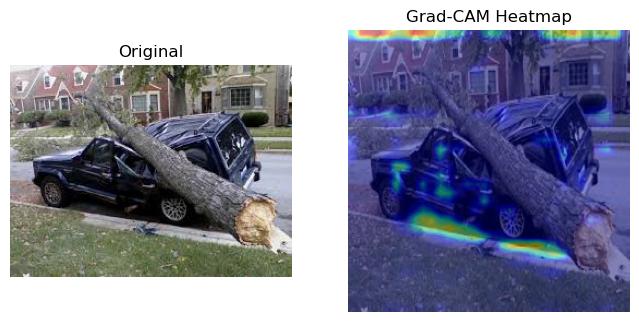

Prediction: Whole
Confidence: 90.6%


In [32]:
# Apne dataset se koi bhi image test karte hain
test_image_path = "data1a/validation/00-damage/" + os.listdir("data1a/validation/00-damage")[0]

image = Image.open(test_image_path).convert('RGB')
tensor = preprocess_image(image)

output = model(tensor)
probs = F.softmax(output, dim=1)[0]
pred_idx = int(torch.argmax(probs).item())
damage_label = "Damaged" if pred_idx == 1 else "Whole"
confidence = float(probs[pred_idx].item())

cam, _ = generate_gradcam(model, tensor, pred_idx)
heatmap_img = overlay_heatmap(cam, image)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(heatmap_img); axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis('off')
plt.show()

print(f"Prediction: {damage_label}")
print(f"Confidence: {confidence:.1%}")

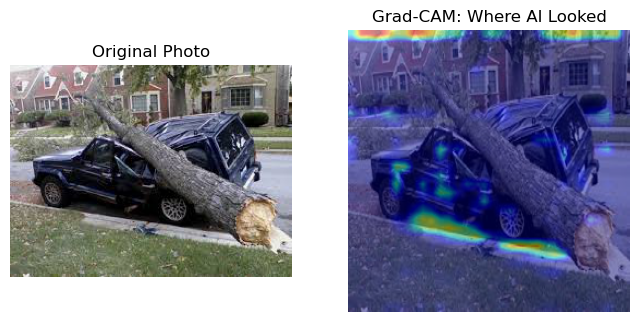

Image Prediction: Whole (90.6% confidence)
Tabular Risk Score: 0/100  |  Reasons: []
Text Risk Score: 0/100  |  Flags: []

AI Recommendation: Auto-Approve (No Damage Detected)

Explanation: The vision model classified the vehicle as Whole with 90.6% confidence. No unusual risk factors in policy/vehicle data. No suspicious language detected in description. Combined assessment: Auto-Approve (No Damage Detected).
PDF generation skipped: No module named 'fpdf'

✅ Claim CLM-20260712020148 logged. Human decision: Approve


In [33]:
# ============ YAHAN APNE VALUES BADLO ============
test_image_path = "data1a/validation/00-damage/" + os.listdir("data1a/validation/00-damage")[0]
vehicle_age_val = 8
mileage_val = 60000
repair_cost_val = 3000
policy_type_val = "Comprehensive"
claim_description = "Front bumper was hit while parked overnight"
human_decision_val = "Approve"
# ===================================================

image = Image.open(test_image_path).convert('RGB')
tensor = preprocess_image(image)

output = model(tensor)
probs = F.softmax(output, dim=1)[0]
pred_idx = int(torch.argmax(probs).item())
damage_label = "Damaged" if pred_idx == 1 else "Whole"
confidence = float(probs[pred_idx].item())

cam, _ = generate_gradcam(model, tensor, pred_idx)
heatmap_img = overlay_heatmap(cam, image)

t_risk, t_reasons = compute_tabular_risk(vehicle_age_val, mileage_val, repair_cost_val, policy_type_val)
tx_risk, tx_flags = analyze_claim_text(claim_description)
decision = compute_final_decision(damage_label, confidence, t_risk, tx_risk)
explanation = generate_explanation(damage_label, confidence, t_risk, t_reasons, tx_risk, tx_flags, decision)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image); axes[0].set_title("Original Photo"); axes[0].axis('off')
axes[1].imshow(heatmap_img); axes[1].set_title("Grad-CAM: Where AI Looked"); axes[1].axis('off')
plt.show()

print(f"Image Prediction: {damage_label} ({confidence:.1%} confidence)")
print(f"Tabular Risk Score: {t_risk}/100  |  Reasons: {t_reasons}")
print(f"Text Risk Score: {tx_risk}/100  |  Flags: {tx_flags}")
print(f"\nAI Recommendation: {decision}")
print(f"\nExplanation: {explanation}")

claim_id = "CLM-" + datetime.now().strftime("%Y%m%d%H%M%S")
result_dict = dict(damage_label=damage_label, confidence=confidence, tabular_risk=t_risk,
                    text_risk=tx_risk, final_decision=decision, explanation=explanation)

log_decision(claim_id, damage_label, confidence, t_risk, tx_risk, decision, human_decision_val, "Reviewed during demo")
pdf_path = generate_pdf_report(claim_id, result_dict, human_decision_val)

print(f"\n✅ Claim {claim_id} logged. Human decision: {human_decision_val}")
if pdf_path:
    print(f"✅ PDF report saved: {pdf_path}")

In [34]:
!pip install fpdf2 --quiet
print("Done")

Done


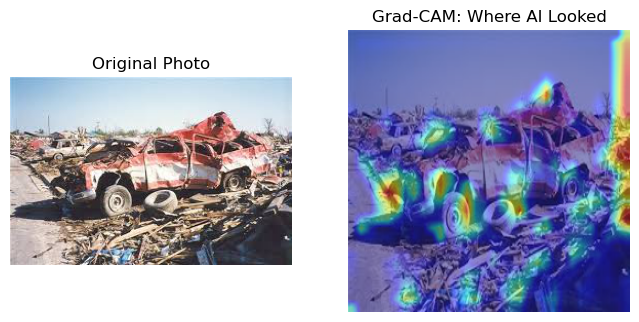

Image Prediction: Damaged (74.3% confidence)
Tabular Risk Score: 0/100  |  Reasons: []
Text Risk Score: 0/100  |  Flags: []

AI Recommendation: Route to Human Adjuster

Explanation: The vision model classified the vehicle as Damaged with 74.3% confidence. No unusual risk factors in policy/vehicle data. No suspicious language detected in description. Combined assessment: Route to Human Adjuster.
PDF generation skipped: Not enough horizontal space to render a single character

✅ Claim CLM-20260712021217 logged. Human decision: Approve


C:\Users\dell\AppData\Local\Temp\ipykernel_1564\2338691169.py:85: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", "B", 16)
C:\Users\dell\AppData\Local\Temp\ipykernel_1564\2338691169.py:88: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", "", 11)


In [38]:
image = Image.open(test_image_path).convert('RGB')
tensor = preprocess_image(image)

output = model(tensor)
probs = F.softmax(output, dim=1)[0]
pred_idx = int(torch.argmax(probs).item())
damage_label = "Damaged" if pred_idx == 1 else "Whole"
confidence = float(probs[pred_idx].item())

cam, _ = generate_gradcam(model, tensor, pred_idx)
heatmap_img = overlay_heatmap(cam, image)

t_risk, t_reasons = compute_tabular_risk(vehicle_age_val, mileage_val, repair_cost_val, policy_type_val)
tx_risk, tx_flags = analyze_claim_text(claim_description)
decision = compute_final_decision(damage_label, confidence, t_risk, tx_risk)
explanation = generate_explanation(damage_label, confidence, t_risk, t_reasons, tx_risk, tx_flags, decision)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image); axes[0].set_title("Original Photo"); axes[0].axis('off')
axes[1].imshow(heatmap_img); axes[1].set_title("Grad-CAM: Where AI Looked"); axes[1].axis('off')
plt.show()

print(f"Image Prediction: {damage_label} ({confidence:.1%} confidence)")
print(f"Tabular Risk Score: {t_risk}/100  |  Reasons: {t_reasons}")
print(f"Text Risk Score: {tx_risk}/100  |  Flags: {tx_flags}")
print(f"\nAI Recommendation: {decision}")
print(f"\nExplanation: {explanation}")

claim_id = "CLM-" + datetime.now().strftime("%Y%m%d%H%M%S")
result_dict = dict(damage_label=damage_label, confidence=confidence, tabular_risk=t_risk,
                    text_risk=tx_risk, final_decision=decision, explanation=explanation)

log_decision(claim_id, damage_label, confidence, t_risk, tx_risk, decision, human_decision_val, "Reviewed during demo")
pdf_path = generate_pdf_report(claim_id, result_dict, human_decision_val)

print(f"\n✅ Claim {claim_id} logged. Human decision: {human_decision_val}")
if pdf_path:
    print(f"✅ PDF report saved: {pdf_path}")

In [39]:
def generate_pdf_report(claim_id, r, human_decision_value):
    try:
        from fpdf import FPDF
        pdf = FPDF()
        pdf.add_page()
        pdf.set_font("helvetica", "B", 16)
        pdf.cell(0, 10, "AI Insurance Claim Assessment Report")
        pdf.ln(14)
        pdf.set_font("helvetica", "", 11)
        lines = [
            f"Claim ID: {claim_id}",
            f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
            f"AI Damage Assessment: {r['damage_label']} ({r['confidence']:.1%} confidence)",
            f"Tabular Risk Score: {r['tabular_risk']}/100",
            f"Text Risk Score: {r['text_risk']}/100",
            f"AI Recommendation: {r['final_decision']}",
        ]
        for line in lines:
            pdf.multi_cell(0, 8, line)
        pdf.ln(4)
        pdf.multi_cell(0, 8, f"Explanation: {r['explanation']}")
        pdf.ln(4)
        pdf.multi_cell(0, 8, f"Human Reviewer Decision: {human_decision_value}")
        filename = f"{claim_id}_report.pdf"
        pdf.output(filename)
        return filename
    except Exception as e:
        print("PDF generation skipped:", e)
        return None

print("PDF function updated")

PDF function updated


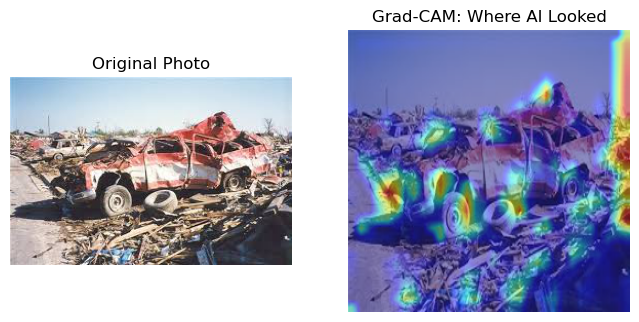

Image Prediction: Damaged (74.3% confidence)
Tabular Risk Score: 0/100  |  Reasons: []
Text Risk Score: 0/100  |  Flags: []

AI Recommendation: Route to Human Adjuster

Explanation: The vision model classified the vehicle as Damaged with 74.3% confidence. No unusual risk factors in policy/vehicle data. No suspicious language detected in description. Combined assessment: Route to Human Adjuster.
PDF generation skipped: Not enough horizontal space to render a single character

✅ Claim CLM-20260712021416 logged. Human decision: Approve


In [40]:
image = Image.open(test_image_path).convert('RGB')
tensor = preprocess_image(image)

output = model(tensor)
probs = F.softmax(output, dim=1)[0]
pred_idx = int(torch.argmax(probs).item())
damage_label = "Damaged" if pred_idx == 1 else "Whole"
confidence = float(probs[pred_idx].item())

cam, _ = generate_gradcam(model, tensor, pred_idx)
heatmap_img = overlay_heatmap(cam, image)

t_risk, t_reasons = compute_tabular_risk(vehicle_age_val, mileage_val, repair_cost_val, policy_type_val)
tx_risk, tx_flags = analyze_claim_text(claim_description)
decision = compute_final_decision(damage_label, confidence, t_risk, tx_risk)
explanation = generate_explanation(damage_label, confidence, t_risk, t_reasons, tx_risk, tx_flags, decision)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image); axes[0].set_title("Original Photo"); axes[0].axis('off')
axes[1].imshow(heatmap_img); axes[1].set_title("Grad-CAM: Where AI Looked"); axes[1].axis('off')
plt.show()

print(f"Image Prediction: {damage_label} ({confidence:.1%} confidence)")
print(f"Tabular Risk Score: {t_risk}/100  |  Reasons: {t_reasons}")
print(f"Text Risk Score: {tx_risk}/100  |  Flags: {tx_flags}")
print(f"\nAI Recommendation: {decision}")
print(f"\nExplanation: {explanation}")

claim_id = "CLM-" + datetime.now().strftime("%Y%m%d%H%M%S")
result_dict = dict(damage_label=damage_label, confidence=confidence, tabular_risk=t_risk,
                    text_risk=tx_risk, final_decision=decision, explanation=explanation)

log_decision(claim_id, damage_label, confidence, t_risk, tx_risk, decision, human_decision_val, "Reviewed during demo")
pdf_path = generate_pdf_report(claim_id, result_dict, human_decision_val)

print(f"\n✅ Claim {claim_id} logged. Human decision: {human_decision_val}")
if pdf_path:
    print(f"✅ PDF report saved: {pdf_path}")

In [41]:
def generate_pdf_report(claim_id, r, human_decision_value):
    try:
        from fpdf import FPDF
        pdf = FPDF()
        pdf.set_auto_page_break(auto=True, margin=15)
        pdf.add_page()
        page_width = pdf.w - pdf.l_margin - pdf.r_margin

        pdf.set_font("helvetica", "B", 16)
        pdf.set_x(pdf.l_margin)
        pdf.cell(page_width, 10, "AI Insurance Claim Assessment Report")
        pdf.ln(14)

        pdf.set_font("helvetica", "", 11)
        lines = [
            f"Claim ID: {claim_id}",
            f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
            f"AI Damage Assessment: {r['damage_label']} ({r['confidence']:.1%} confidence)",
            f"Tabular Risk Score: {r['tabular_risk']}/100",
            f"Text Risk Score: {r['text_risk']}/100",
            f"AI Recommendation: {r['final_decision']}",
        ]
        for line in lines:
            pdf.set_x(pdf.l_margin)
            pdf.multi_cell(page_width, 8, line)

        pdf.ln(4)
        pdf.set_x(pdf.l_margin)
        pdf.multi_cell(page_width, 8, f"Explanation: {r['explanation']}")

        pdf.ln(4)
        pdf.set_x(pdf.l_margin)
        pdf.multi_cell(page_width, 8, f"Human Reviewer Decision: {human_decision_value}")

        filename = f"{claim_id}_report.pdf"
        pdf.output(filename)
        return filename
    except Exception as e:
        # fallback: agar PDF phir bhi fail ho, ek simple text report bana do
        print("PDF failed, saving as text report instead:", e)
        filename = f"{claim_id}_report.txt"
        with open(filename, "w") as f:
            f.write("AI Insurance Claim Assessment Report\n\n")
            f.write(f"Claim ID: {claim_id}\n")
            f.write(f"AI Damage Assessment: {r['damage_label']} ({r['confidence']:.1%} confidence)\n")
            f.write(f"Tabular Risk Score: {r['tabular_risk']}/100\n")
            f.write(f"Text Risk Score: {r['text_risk']}/100\n")
            f.write(f"AI Recommendation: {r['final_decision']}\n\n")
            f.write(f"Explanation: {r['explanation']}\n\n")
            f.write(f"Human Reviewer Decision: {human_decision_value}\n")
        return filename

print("PDF function fixed")

PDF function fixed


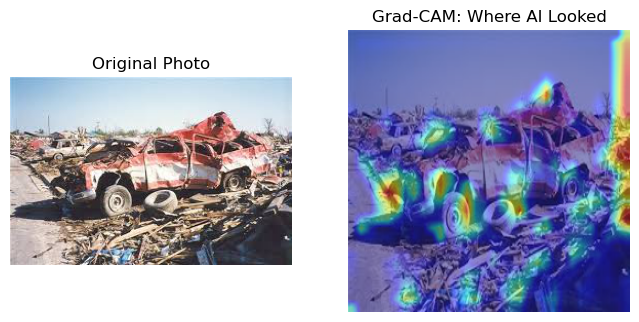

Image Prediction: Damaged (74.3% confidence)
Tabular Risk Score: 0/100  |  Reasons: []
Text Risk Score: 0/100  |  Flags: []

AI Recommendation: Route to Human Adjuster

Explanation: The vision model classified the vehicle as Damaged with 74.3% confidence. No unusual risk factors in policy/vehicle data. No suspicious language detected in description. Combined assessment: Route to Human Adjuster.

✅ Claim CLM-20260712021605 logged. Human decision: Approve
✅ Report saved: CLM-20260712021605_report.pdf


In [42]:
image = Image.open(test_image_path).convert('RGB')
tensor = preprocess_image(image)

output = model(tensor)
probs = F.softmax(output, dim=1)[0]
pred_idx = int(torch.argmax(probs).item())
damage_label = "Damaged" if pred_idx == 1 else "Whole"
confidence = float(probs[pred_idx].item())

cam, _ = generate_gradcam(model, tensor, pred_idx)
heatmap_img = overlay_heatmap(cam, image)

t_risk, t_reasons = compute_tabular_risk(vehicle_age_val, mileage_val, repair_cost_val, policy_type_val)
tx_risk, tx_flags = analyze_claim_text(claim_description)
decision = compute_final_decision(damage_label, confidence, t_risk, tx_risk)
explanation = generate_explanation(damage_label, confidence, t_risk, t_reasons, tx_risk, tx_flags, decision)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image); axes[0].set_title("Original Photo"); axes[0].axis('off')
axes[1].imshow(heatmap_img); axes[1].set_title("Grad-CAM: Where AI Looked"); axes[1].axis('off')
plt.show()

print(f"Image Prediction: {damage_label} ({confidence:.1%} confidence)")
print(f"Tabular Risk Score: {t_risk}/100  |  Reasons: {t_reasons}")
print(f"Text Risk Score: {tx_risk}/100  |  Flags: {tx_flags}")
print(f"\nAI Recommendation: {decision}")
print(f"\nExplanation: {explanation}")

claim_id = "CLM-" + datetime.now().strftime("%Y%m%d%H%M%S")
result_dict = dict(damage_label=damage_label, confidence=confidence, tabular_risk=t_risk,
                    text_risk=tx_risk, final_decision=decision, explanation=explanation)

log_decision(claim_id, damage_label, confidence, t_risk, tx_risk, decision, human_decision_val, "Reviewed during demo")
pdf_path = generate_pdf_report(claim_id, result_dict, human_decision_val)

print(f"\n✅ Claim {claim_id} logged. Human decision: {human_decision_val}")
if pdf_path:
    print(f"✅ Report saved: {pdf_path}")